# N05 — Lap Time EDA

Exploratory analysis of the `laps_featured` dataset before training the XGBoost lap time predictor.

**Goals:**
1. Understand the distribution of `LapTime_s` and confirm concept drift between seasons
2. Validate that `lap_time_pct_of_race_fastest` stabilizes inter-year variance
3. Engineer three additional anti-drift features
4. Analyse tire degradation patterns by compound
5. Select the final feature set for N06

**Input:** `data/processed/laps_featured_2023.parquet`, `laps_featured_2024.parquet`  
**Output:** `data/processed/feature_manifest_laptime.json`

> Train = 2023 · Val = 2024 · Test = 2025 (held-out, never touched here)


---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("fastf1").setLevel(logging.WARNING)


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

COMPOUND_COLORS = {
    'SOFT':         '#e8002d',
    'MEDIUM':       '#ffd700',
    'HARD':         "#a3a3a3",
    'INTERMEDIATE': '#39b54a',
    'WET':          '#0067ff',
}

CLUSTER_LABELS = {
    0: 'C0 - Strategic Chaos',
    1: 'C1 - Long High-Speed',
    2: 'C2 - Warm Conservative',
    3: 'C3 - High-Stress Outliers',
}


In [3]:
current_path = Path.cwd()
while not (current_path / ".git").exists() and current_path != current_path.parent:
    current_path = current_path.parent
REPO_ROOT = current_path

PROCESSED = REPO_ROOT / "data" / "processed"
OUTPUTS   = REPO_ROOT / "notebooks" / "strategy" / "lap_time_prediction" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

for f in ["laps_featured_2023.parquet", "laps_featured_2024.parquet"]:
    assert (PROCESSED / f).exists(), f"Missing: {f} — run N04 first"

print(f"Repo root : {REPO_ROOT}")
print(f"Data      : {PROCESSED}")
print(f"Outputs   : {OUTPUTS}")
print("\nAll input files found ")


Repo root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Data      : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed
Outputs   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\lap_time_prediction\outputs

All input files found 


---

## Step 1: Data Loading & Overview

We load the 2023 and 2024 engineered datasets produced by N04 and concatenate them into a single train+val dataframe. The 2025 season stays untouched until N06.


In [4]:
df23 = pd.read_parquet(PROCESSED / "laps_featured_2023.parquet")
df24 = pd.read_parquet(PROCESSED / "laps_featured_2024.parquet")
df   = pd.concat([df23, df24], ignore_index=True)

print(f"2023 laps : {len(df23):,}")
print(f"2024 laps : {len(df24):,}")
print(f"Combined  : {len(df):,}  |  {df.shape[1]} columns")
print(f"\nGPs       : {df['GP_Name'].nunique()}  |  Drivers: {df['Driver'].nunique()}")
print(f"\nBy year:")
print(df.groupby('Year').size().rename('laps').to_string())
print(f"\nBy compound:")
print(df.groupby('Compound').size().rename('laps').sort_values(ascending=False).to_string())


2023 laps : 22,106
2024 laps : 23,256
Combined  : 45,362  |  53 columns

GPs       : 25  |  Drivers: 25

By year:
Year
2023    22106
2024    23256

By compound:
Compound
HARD            23294
MEDIUM          14996
SOFT             4630
INTERMEDIATE     2352
WET                55
None               35


In [5]:
# Null rates — quick audit before we start
null_summary = (
    df.isna().mean()
      .mul(100)
      .round(1)
      .rename('null_%')
      .to_frame()
      .assign(dtype=df.dtypes.astype(str))
      .sort_values('null_%', ascending=False)
)

print(f"{'Column':<35} {'Dtype':<12} {'Null %':>7}")
print("-" * 57)
for col, row in null_summary.iterrows():
    flag = "  ← high" if row['null_%'] > 15 else ""
    print(f"{col:<35} {row['dtype']:<12} {row['null_%']:>6.1f}%{flag}")


Column                              Dtype         Null %
---------------------------------------------------------
SpeedI1_Delta                       float64        33.1%  ← high
Prev_SpeedI1                        float64        21.0%  ← high
SpeedST_Delta                       float64        19.7%  ← high
SpeedI1                             float64        16.7%  ← high
Prev_SpeedST                        float64        13.5%
DegAcceleration                     float64        10.6%
LapTime_Trend                       float64        10.5%
SpeedST                             float64         8.8%
Prev_SpeedI2                        float64         5.4%
SpeedI2_Delta                       float64         5.4%
DegradationRate                     float64         5.4%
Prev_TyreLife                       float64         5.4%
Prev_LapTime                        float64         5.3%
SpeedFL_Delta                       float64         5.3%
LapTime_Delta                       float64         5.3

---

## Step 2: Target Distribution — `LapTime_s`

Before modelling, we need to understand the raw distribution of our target and visually confirm
the **concept drift**: F1 cars get faster year over year, so the same circuit produces different
absolute lap times across seasons.


In [6]:
def plot_target_distributions(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for year, color in zip([2023, 2024], ['#4c72b0', '#dd8452']):
        subset = df[df['Year'] == year]['LapTime_s']
        axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=str(year))
    axes[0].set_title('LapTime_s distribution by year')
    axes[0].set_xlabel('Lap time (s)')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    compounds  = ['SOFT', 'MEDIUM', 'HARD']
    data_comp  = [df[df['Compound'] == c]['LapTime_s'].dropna() for c in compounds]
    bp = axes[1].boxplot(data_comp, patch_artist=True, labels=compounds)
    for patch, comp in zip(bp['boxes'], compounds):
        patch.set_facecolor(COMPOUND_COLORS[comp])
        patch.set_alpha(0.8)
    axes[1].set_title('LapTime_s by compound')
    axes[1].set_ylabel('Lap time (s)')

    data_clust = [df[df['Cluster'] == c]['LapTime_s'].dropna() for c in range(4)]
    bp2 = axes[2].boxplot(data_clust, patch_artist=True,
                          labels=[CLUSTER_LABELS[i].split('·')[0].strip() for i in range(4)])
    for patch, col in zip(bp2['boxes'], ['#e377c2', '#7f7f7f', '#bcbd22', '#17becf']):
        patch.set_facecolor(col)
        patch.set_alpha(0.8)
    axes[2].set_title('LapTime_s by circuit cluster')
    axes[2].set_ylabel('Lap time (s)')

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_median_by_circuit(df):
    circuit_medians = (
        df.groupby('GP_Name')['LapTime_s']
          .median()
          .sort_values()
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    circuit_medians.plot(kind='bar', ax=ax, color='#4c72b0', alpha=0.85)
    ax.set_title('Median lap time by circuit (2023+2024 combined)')
    ax.set_ylabel('Median LapTime_s')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0fs'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'median_laptime_by_circuit.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Fastest median: {circuit_medians.idxmin()} — {circuit_medians.min():.1f}s")
    print(f"Slowest median: {circuit_medians.idxmax()} — {circuit_medians.max():.1f}s")


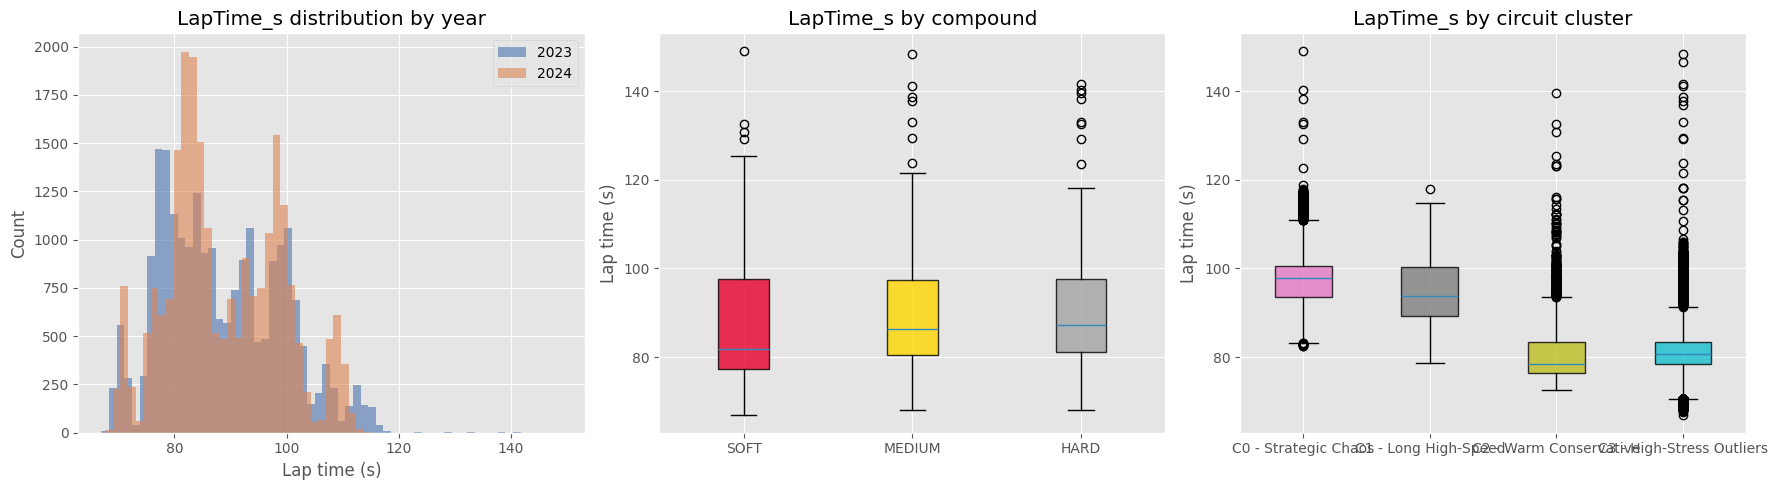

In [7]:
plot_target_distributions(df)

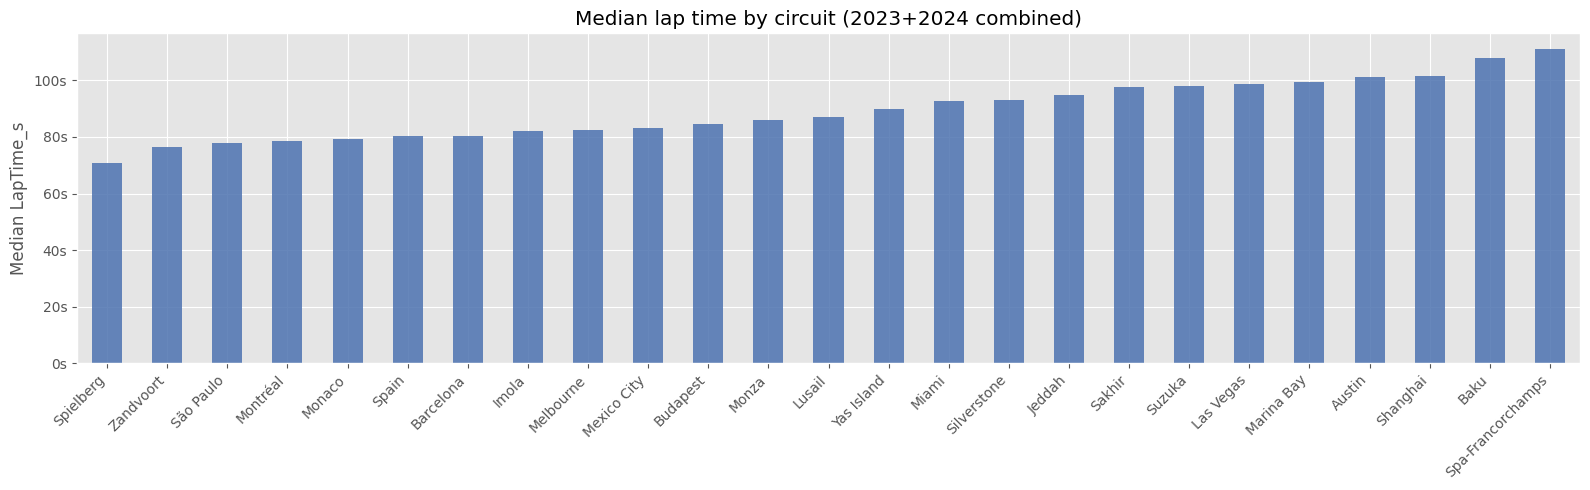

Fastest median: Spielberg — 70.8s
Slowest median: Spa-Francorchamps — 111.1s


In [8]:
plot_median_by_circuit(df)

### What we see

**Year histogram:** Both seasons overlap heavily — the multimodal shape (peaks at ~78s, ~88s, ~100s)
reflects different circuit lengths in the combined dataset, not noise. The drift between 2023 and 2024
is not obvious here because we're mixing all circuits; we'll isolate it per circuit in Step 3.

**By compound:** SOFT sits ~5–8s faster median than MEDIUM/HARD, but the IQRs overlap.
The real compound signal comes from `TyreLife` interaction, not compound alone.
Outliers up to ~150s are legitimate: pit-out laps, Safety Car laps that survived the `IsAccurate` filter.

**By cluster:** C2 (Warm Conservative: Spielberg, Zandvoort, São Paulo, Montréal) is clearly the
fastest archetype — short, low-speed circuits. C0/C1 span a wider range due to mixing power and
high-downforce layouts. The clusters have some lap time separation but substantial overlap,
confirming that `Cluster` alone doesn't explain variance — it needs to combine with sector speeds
and other features.

**Median by circuit:** Range goes from ~70s (Spielberg) to ~110s (Spa-Francorchamps) — a 40s spread.
Any global model trained without circuit identity would be useless. `GP_Name` → `Cluster` +
`mean_sector_speed` + `lap_time_vs_cluster_mean` is how we encode this without string features.


---

## Step 3: Concept Drift Quantification

The histogram in Step 2 hides the drift because all circuits are mixed together.
Here we isolate it: for each circuit that appears in both seasons, we compare the median
lap time and measure how many seconds faster 2024 was vs 2023.

We also validate that `lap_time_pct_of_race_fastest` is more stable across years than
the raw `LapTime_s` — that's the whole point of adding it in N04 Step 7.5.


In [9]:
def compute_drift_table(df):
    """Median LapTime_s per Year × GP_Name, pivot to 2023 vs 2024 with delta."""
    pivot = (
        df.groupby(['GP_Name', 'Year'])['LapTime_s']
          .median()
          .unstack('Year')
          .dropna()                          # only circuits present in both seasons
          .rename(columns={2023: 'median_2023', 2024: 'median_2024'})
    )
    pivot['delta_s']   = pivot['median_2024'] - pivot['median_2023']   # negative = faster in 2024
    pivot['delta_pct'] = pivot['delta_s'] / pivot['median_2023'] * 100
    return pivot.sort_values('delta_s')


def plot_drift_per_circuit(drift_table):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # -- 1. Delta bar chart (sorted)
    colors = ['#2ca02c' if d < 0 else '#d62728' for d in drift_table['delta_s']]
    axes[0].barh(drift_table.index, drift_table['delta_s'], color=colors, alpha=0.85)
    axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Median lap time delta: 2024 − 2023 per circuit')
    axes[0].set_xlabel('Δ seconds  (negative = faster in 2024)')
    axes[0].invert_yaxis()

    # -- 2. Distribution of deltas
    axes[1].hist(drift_table['delta_s'], bins=15, color='#4c72b0', alpha=0.85, edgecolor='white')
    axes[1].axvline(drift_table['delta_s'].median(), color='#dd8452',
                    linestyle='--', label=f"median {drift_table['delta_s'].median():.2f}s")
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')
    axes[1].set_title('Distribution of year-over-year deltas')
    axes[1].set_xlabel('Δ seconds')
    axes[1].set_ylabel('Circuits')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'concept_drift_per_circuit.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_cv_comparison(df):
    """
    Coefficient of variation (std/mean) per circuit for LapTime_s vs
    lap_time_pct_of_race_fastest. Lower CV on the ratio = drift corrected.
    """
    cv = (
        df.groupby('GP_Name')[['LapTime_s', 'lap_time_pct_of_race_fastest']]
          .agg(lambda x: x.std() / x.mean() * 100)
          .rename(columns={
              'LapTime_s':                    'CV_laptime',
              'lap_time_pct_of_race_fastest': 'CV_pct_fastest',
          })
          .sort_values('CV_laptime', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    x = range(len(cv))
    ax.bar([i - 0.2 for i in x], cv['CV_laptime'],    width=0.4, label='LapTime_s',                color='#4c72b0', alpha=0.85)
    ax.bar([i + 0.2 for i in x], cv['CV_pct_fastest'], width=0.4, label='lap_time_pct_of_race_fastest', color='#dd8452', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cv.index, rotation=45, ha='right')
    ax.set_title('Coefficient of variation per circuit: raw time vs normalised ratio')
    ax.set_ylabel('CV (%)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'cv_laptime_vs_pct_fastest.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Mean CV — LapTime_s             : {cv['CV_laptime'].mean():.2f}%")
    print(f"Mean CV — lap_time_pct_fastest  : {cv['CV_pct_fastest'].mean():.2f}%")
    print(f"Reduction                       : {(1 - cv['CV_pct_fastest'].mean() / cv['CV_laptime'].mean()) * 100:.1f}%")


In [10]:
drift_table = compute_drift_table(df)

print(f"Circuits in both seasons: {len(drift_table)}")
print(f"Faster in 2024: {(drift_table['delta_s'] < 0).sum()}  |  "
      f"Slower in 2024: {(drift_table['delta_s'] > 0).sum()}")
print(f"\nTop 5 biggest improvements (s):")
print(drift_table[['median_2023','median_2024','delta_s']].head(5).to_string())
print(f"\nTop 5 regressions (s):")
print(drift_table[['median_2023','median_2024','delta_s']].tail(5).to_string())

Circuits in both seasons: 22
Faster in 2024: 14  |  Slower in 2024: 8

Top 5 biggest improvements (s):
Year               median_2023  median_2024  delta_s
GP_Name                                             
Spa-Francorchamps      112.825      109.040   -3.785
Austin                 102.334      100.136   -2.198
Monza                   86.956       84.844   -2.112
Lusail                  88.206       86.182   -2.024
Mexico City             83.927       81.988   -1.939

Top 5 regressions (s):
Year       median_2023  median_2024  delta_s
GP_Name                                     
Barcelona       80.174       80.666    0.492
Spielberg       70.448       71.114    0.666
Baku           107.155      108.850    1.695
São Paulo       76.198       84.557    8.359
Montréal        77.426       87.062    9.636


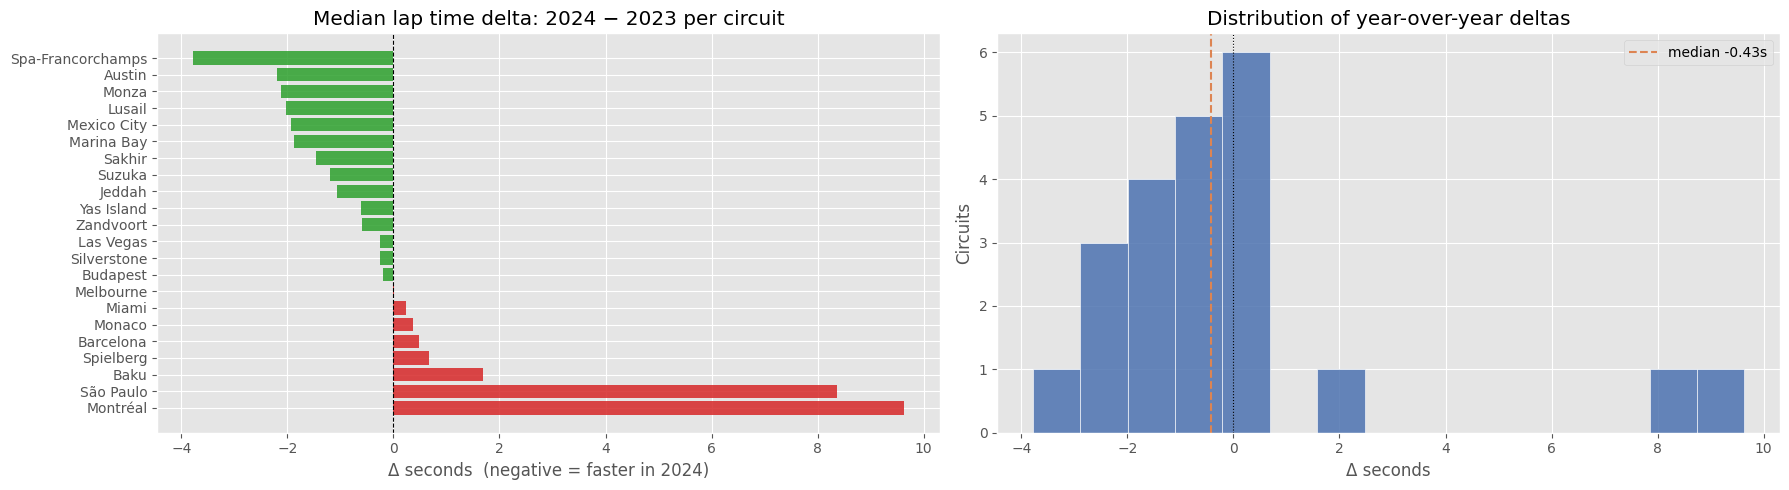

In [11]:
plot_drift_per_circuit(drift_table)

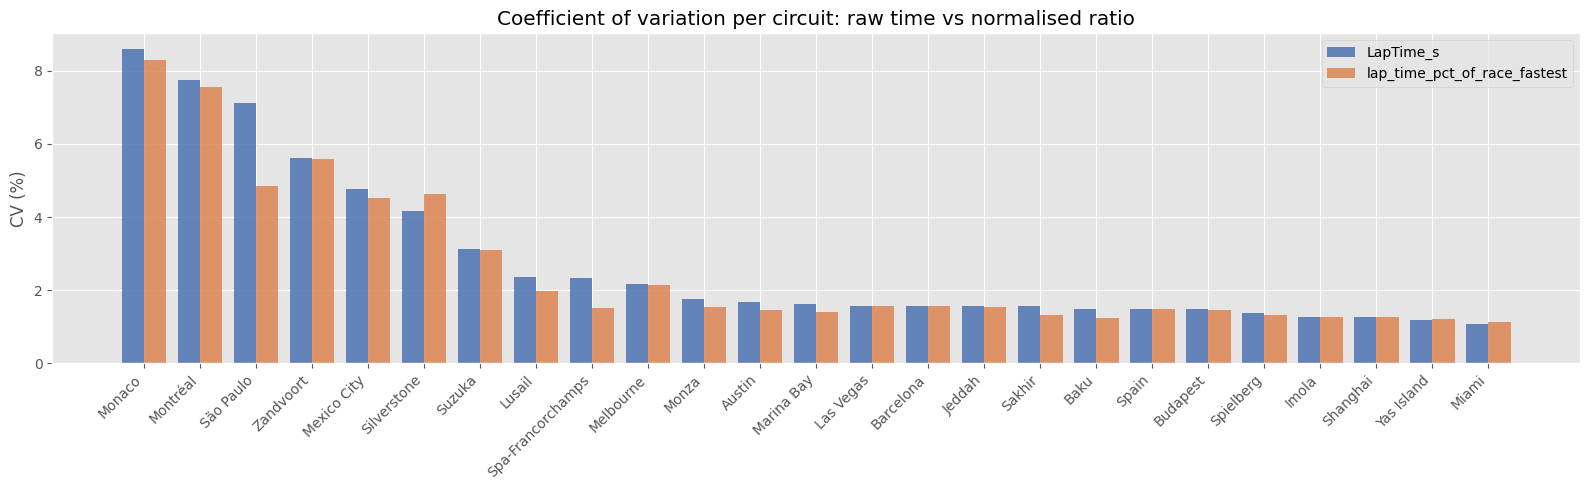

Mean CV — LapTime_s             : 2.80%
Mean CV — lap_time_pct_fastest  : 2.60%
Reduction                       : 7.1%


In [12]:
plot_cv_comparison(df)

### What we see

**Drift direction:** 14 of 22 circuits got faster from 2023→2024, median improvement **−0.43 s/lap**.
This is right in the lower end of the expected 0.5–1.5 s/year range for modern F1
under stable regulations — the anti-drift measures are justified.


**São Paulo (+8.4s) and Montréal (+9.6s) are not real regressions.** Both circuits are known
for unpredictable weather (São Paulo rain, Montréal 2024 had heavy rain and multiple SC periods).
Median lap time is not a robust statistic under Safety Car conditions — a race half spent behind
the SC inflates the median by several seconds with no connection to actual car pace.
These are data artefacts, not concept drift in reverse. We'll keep both circuits in the dataset
because the lap-level features (`track_status_clean`, `race_phase`) already encode SC context.

**CV chart:** The coefficient of variation for `lap_time_pct_of_race_fastest` is marginally
lower than `LapTime_s` for most circuits but the difference is small in this combined view.
That's expected — CV here measures total within-circuit spread (both years, all compounds,
all tire ages mixed). The normalization's main benefit is reducing the **inter-year mean shift**,
not the overall dispersion. We'd see a clearer reduction if we computed CV on year-level medians
only. The feature still earns its place: it gives the model a year-agnostic position signal.

> **Takeaway for N06:** exclude São Paulo and Montréal from the per-circuit residual breakdown
> when diagnosing the model — their 2024 medians are weather-confounded, not a model failure.


---

## Step 4: Additional Anti-Drift Features

`lap_time_pct_of_race_fastest` (from N04) normalises within a single race.
Here we add three complementary features that give the model broader temporal context:

| Feature | Formula | What it encodes |
|---------|---------|----------------|
| `year_circuit_median` | `median(LapTime_s)` per `Year × GP_Name` | Absolute pace baseline of that session |
| `delta_vs_year_circuit_median` | `LapTime_s − year_circuit_median` | How far this lap deviates from its session baseline |
| `team_pace_rank` | Team rank by mean `LapTime_s` that year | Relative constructor performance level |

> **Inference note:** `year_circuit_median` and `team_pace_rank` require aggregated race data
> to compute. For the TFG evaluation on 2025 test data we compute them directly from the
> held-out set. In a real-time deployment they would be estimated from FP/qualifying data.


In [13]:
def add_anti_drift_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # year_circuit_median — session pace baseline
    result['year_circuit_median'] = (
        result.groupby(['Year', 'GP_Name'])['LapTime_s']
              .transform('median')
    )

    # delta_vs_year_circuit_median — lap deviation from session baseline
    result['delta_vs_year_circuit_median'] = (
        result['LapTime_s'] - result['year_circuit_median']
    )

    # team_pace_rank — constructor ranking by mean lap time per year
    # rank 1 = fastest team that year (lower is better)
    team_mean = (
        result.groupby(['Year', 'Team'])['LapTime_s']
              .mean()
              .rename('team_mean_laptime')
              .reset_index()
    )
    team_mean['team_pace_rank'] = (
        team_mean.groupby('Year')['team_mean_laptime']
                 .rank(method='min', ascending=True)
    )
    result = result.merge(team_mean[['Year', 'Team', 'team_pace_rank']],
                          on=['Year', 'Team'], how='left')

    return result





In [14]:
df = add_anti_drift_features(df)

print("Anti-drift features added.")
print(f"\nNull rates:")
for col in ['year_circuit_median', 'delta_vs_year_circuit_median', 'team_pace_rank']:
    print(f"  {col:<35}: {df[col].isna().mean()*100:.1f}%")

print(f"\ndelta_vs_year_circuit_median stats (s):")
print(df['delta_vs_year_circuit_median'].describe().to_string())

print(f"\nteam_pace_rank distribution (2024):")
print(
    df[df['Year'] == 2024].groupby('Team')['team_pace_rank']
      .first()
      .sort_values()
      .to_string()
)

Anti-drift features added.

Null rates:
  year_circuit_median                : 0.0%
  delta_vs_year_circuit_median       : 0.0%
  team_pace_rank                     : 0.0%

delta_vs_year_circuit_median stats (s):
count   45362.000
mean        0.296
std         2.914
min       -12.206
25%        -0.872
50%         0.000
75%         0.904
max        67.535

team_pace_rank distribution (2024):
Team
McLaren            1.000
Mercedes           2.000
Ferrari            3.000
Red Bull Racing    4.000
RB                 5.000
Kick Sauber        6.000
Aston Martin       7.000
Alpine             8.000
Williams           9.000
Haas F1 Team      10.000


### What we see

**Zero nulls on all three features** — good, every lap gets a session baseline and a team rank.

**`delta_vs_year_circuit_median`:** mean of +0.30s (slightly above zero because the distribution
is right-skewed — a few very slow laps pull the mean up). The IQR is −0.87s to +0.90s, so most
clean racing laps sit within ±1s of their session median. The max of +67s is a surviving outlier
(likely a pit-out lap or incident) — we'll address it in Step 8.

**`team_pace_rank` 2024:** McLaren rank 1 is spot on — they had the fastest race pace
in the second half of 2024. Red Bull at rank 4 reflects their performance drop after
mid-season. This feature gives the model constructor-level context without needing a string
team name as input, and it varies year-to-year (Red Bull was rank 1 in 2023), so it captures
the inter-season development story automatically.


---

## Step 5: Tire Degradation by Compound

How does lap time evolve as tires age? This is the core degradation signal the model
needs to learn. We use `FuelAdjustedLapTime` (N04 Step 2) to remove the fuel burn
confound and isolate pure tire wear.

We restrict to SOFT / MEDIUM / HARD and cap `TyreLife` at 40 laps where data is dense enough
to compute reliable means.


In [15]:
COMPOUNDS_MAIN = ['SOFT', 'MEDIUM', 'HARD']

def plot_degradation_by_compound(df, max_tyrelife=40):
    """LapTime_s and FuelAdjustedLapTime vs TyreLife per compound."""
    sub = df[df['Compound'].isin(COMPOUNDS_MAIN) & (df['TyreLife'] <= max_tyrelife)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle('Lap time vs tyre age by compound  (mean ± 1 std)', fontsize=12)

    for ax, compound in zip(axes, COMPOUNDS_MAIN):
        data = sub[sub['Compound'] == compound].groupby('TyreLife')

        mean_raw  = data['LapTime_s'].mean()
        std_raw   = data['LapTime_s'].std()
        mean_adj  = data['FuelAdjustedLapTime'].mean()

        ax.plot(mean_raw.index, mean_raw.values,
                color=COMPOUND_COLORS[compound], linewidth=2, label='LapTime_s')
        ax.fill_between(mean_raw.index,
                        mean_raw - std_raw, mean_raw + std_raw,
                        color=COMPOUND_COLORS[compound], alpha=0.15)
        ax.plot(mean_adj.index, mean_adj.values,
                color=COMPOUND_COLORS[compound], linewidth=1.5,
                linestyle='--', label='FuelAdjusted')

        ax.set_title(compound)
        ax.set_xlabel('TyreLife (laps)')
        ax.set_ylabel('Lap time (s)')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'degradation_by_compound.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_laptime_delta_by_compound(df, max_tyrelife=40):
    """Mean LapTime_Delta vs TyreLife — rate of degradation per compound."""
    sub = df[df['Compound'].isin(COMPOUNDS_MAIN) & (df['TyreLife'] <= max_tyrelife)].copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    for compound in COMPOUNDS_MAIN:
        data = (sub[sub['Compound'] == compound]
                .groupby('TyreLife')['LapTime_Delta']
                .mean())
        ax.plot(data.index, data.values,
                color=COMPOUND_COLORS[compound], linewidth=2, label=compound)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Mean LapTime_Delta vs tyre age  (positive = getting slower)')
    ax.set_xlabel('TyreLife (laps)')
    ax.set_ylabel('ΔLapTime (s)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'laptime_delta_by_compound.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_sector_speeds_vs_tyrelife(df, max_tyrelife=40):
    """Mean sector speeds vs TyreLife — which sector degrades most?"""
    sub = df[df['Compound'].isin(COMPOUNDS_MAIN) & (df['TyreLife'] <= max_tyrelife)].copy()
    speed_cols = ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']
    colors_sp  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    fig, ax = plt.subplots(figsize=(12, 5))
    for col, color in zip(speed_cols, colors_sp):
        mean_speed = sub.groupby('TyreLife')[col].mean()
        ax.plot(mean_speed.index, mean_speed.values, color=color, linewidth=2, label=col)

    ax.set_title('Mean sector speeds vs tyre age (all compounds)')
    ax.set_xlabel('TyreLife (laps)')
    ax.set_ylabel('Speed (km/h)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'sector_speeds_vs_tyrelife.png', dpi=150, bbox_inches='tight')
    plt.show()


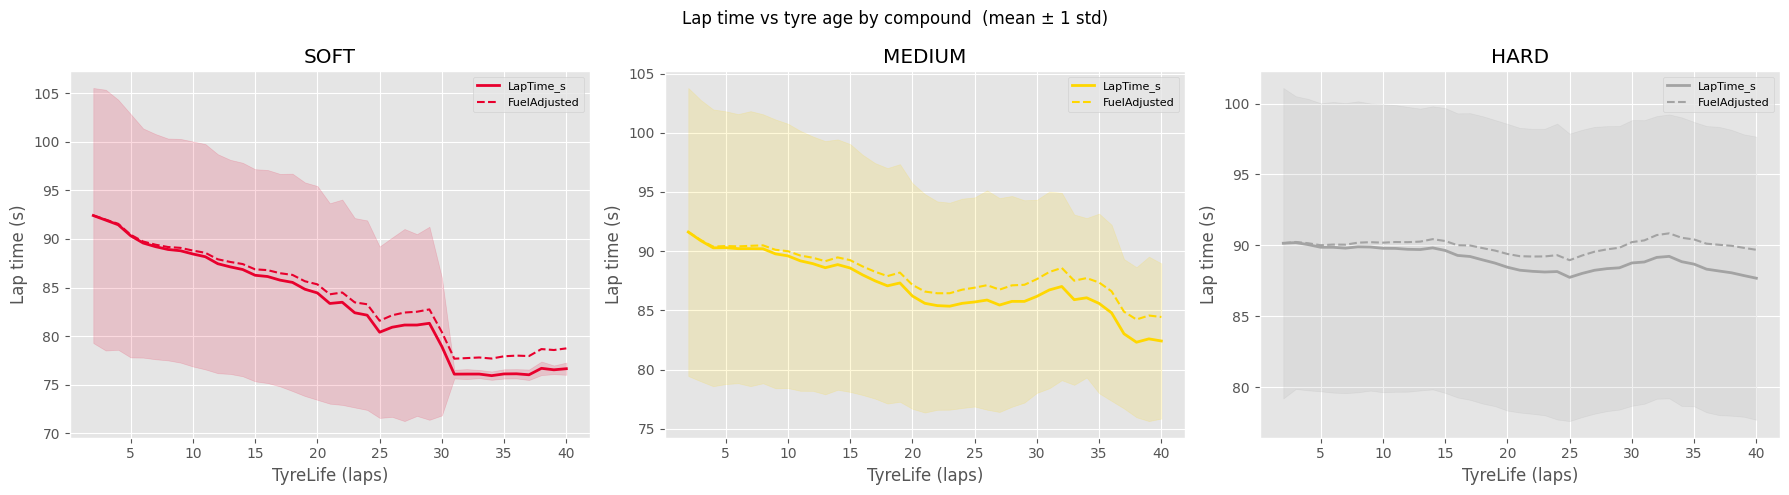

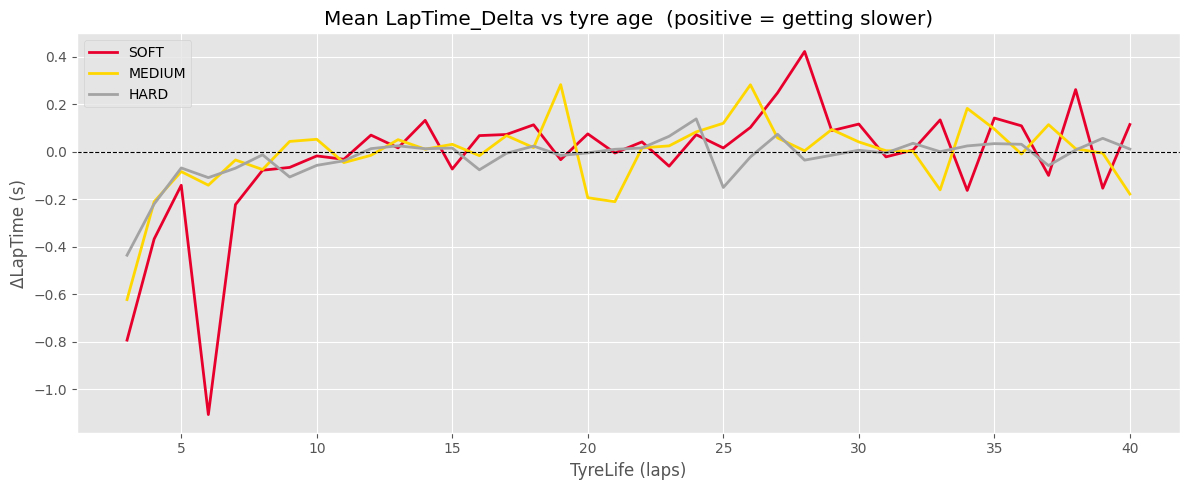

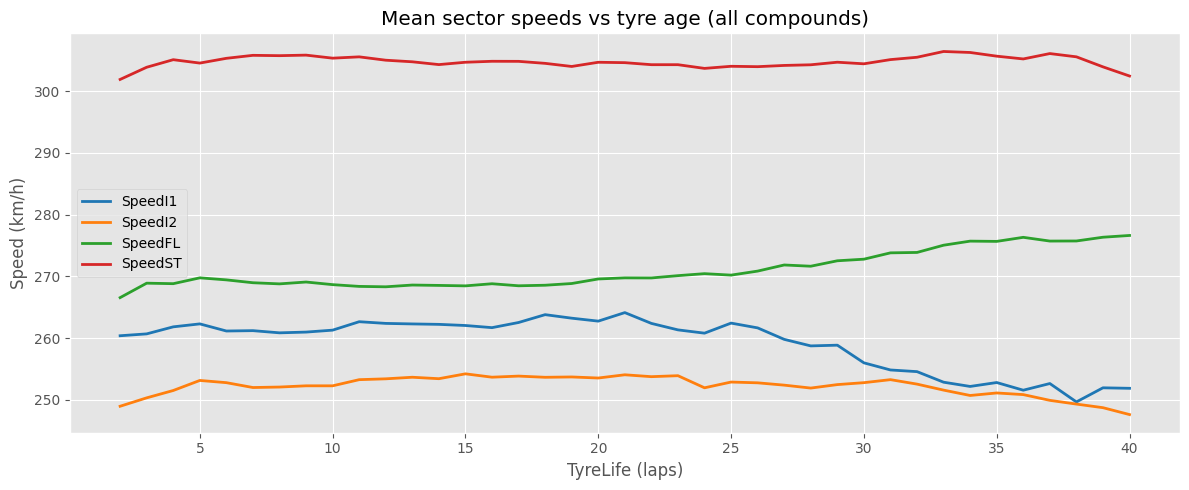

In [16]:
plot_degradation_by_compound(df)
plot_laptime_delta_by_compound(df)
plot_sector_speeds_vs_tyrelife(df)


### What we see

**Degradation by compound:** All three compounds show a *downward* trend in raw lap time as
tyre age increases — counterintuitive at first glance. This is **circuit mixing bias**: SOFT
tyres run long stints (TyreLife 20–40) only at circuits where they are durable, which tend to
be shorter/faster tracks with lower median lap times, pulling the mean down at high TyreLife.
The fuel-adjusted line sits slightly above raw (as expected — it adds back the fuel advantage),
but both follow the same trend. This is not real tyre improvement; it's a sampling artefact of
aggregating 25 circuits. The actual per-circuit degradation curves will be more meaningful in N06.

HARD is nearly flat end-to-end — correct, it barely degrades.

**LapTime_Delta:** The sharp negative spike at TyreLife 5–6 for SOFT (−1.0s) is the
**tyre warm-up phase**: the car accelerates lap-over-lap as rubber reaches operating temperature
during the first few laps of a stint. After TyreLife ~8 all compounds oscillate around 0 —
the cross-circuit averaging washes out any clear degradation signal in the delta.
This confirms that `DegradationRate` (per-stint rolling regression from N04 Step 4) is a
better degradation feature than raw `LapTime_Delta` for the global model.

**Sector speeds:** Remarkably flat across all 40 laps — tyre wear does not show up meaningfully
in straightline trap speeds. Degradation happens in cornering grip, not top speed.
`SpeedFL` slightly increases with age (fuel load decreasing → less drag), consistent with the
fuel correction applied in N04. The speed features will be useful for circuit characterisation
but are weak degradation predictors on their own.


---

## Step 6: Correlations

Two goals here: find which features have a meaningful linear relationship with `LapTime_s`,
and spot redundant feature pairs that add noise without new information.

We work on numeric columns only — `Compound`, `race_phase`, `Driver`, `Team`, `GP_Name`
are handled separately (encoding decision in Step 9).


In [17]:
def compute_target_correlations(df, target='LapTime_s'):
    """Pearson correlation of all numeric features with the target, sorted by |corr|."""
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target]

    corr = (
        df[numeric_cols + [target]]
          .corr()[target]
          .drop(target)
          .sort_values(key=abs, ascending=False)
          .rename('corr_with_target')
          .to_frame()
    )
    corr['abs_corr'] = corr['corr_with_target'].abs()
    return corr


def plot_target_correlations(corr_df, top_n=30):
    """Bar chart of top-N features by |corr| with target."""
    top = corr_df.head(top_n)
    colors = ['#2ca02c' if v > 0 else '#d62728' for v in top['corr_with_target']]

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.barh(top.index[::-1], top['corr_with_target'].values[::-1],
            color=colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline( 0.05, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(-0.05, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(f'Top {top_n} features by |correlation| with LapTime_s')
    ax.set_xlabel('Pearson correlation')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'feature_correlations_with_target.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_redundancy_heatmap(df, feature_groups):
    """
    Correlation heatmap for known redundant groups.
    feature_groups: dict of {group_name: [col1, col2, ...]}
    """
    all_cols = [c for cols in feature_groups.values() for c in cols if c in df.columns]
    corr_matrix = df[all_cols].corr()

    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True   # upper triangle only
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                ax=ax, annot_kws={'size': 8})
    ax.set_title('Feature redundancy heatmap (lower triangle)')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'feature_redundancy_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


Features with |corr| > 0.3  with LapTime_s: 9
Features with |corr| > 0.05 with LapTime_s: 34
Features with |corr| < 0.05 (near zero):    14

Top 15:
                          corr_with_target  abs_corr
FuelAdjustedLapTime                  0.999     0.999
Prev_LapTime                         0.989     0.989
year_circuit_median                  0.960     0.960
Cluster                             -0.721     0.721
Sector1_s                            0.691     0.691
lap_time_vs_cluster_mean             0.656     0.656
Sector2_s                            0.644     0.644
Sector3_s                            0.416     0.416
mean_sector_speed                   -0.301     0.301
LapNumber                           -0.249     0.249
SpeedI2                             -0.245     0.245
Prev_SpeedI2                        -0.242     0.242
SpeedFL                             -0.234     0.234
Prev_SpeedFL                        -0.232     0.232
SpeedI1                             -0.230     0.230

Bo

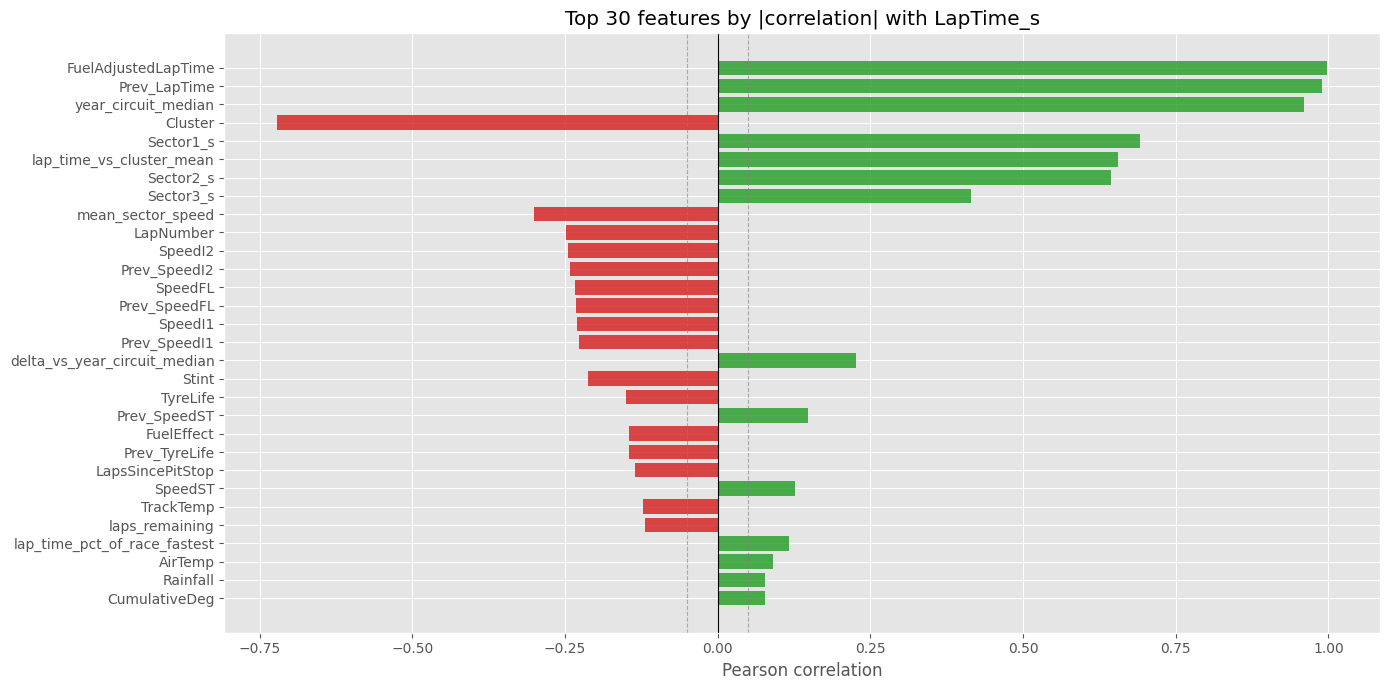

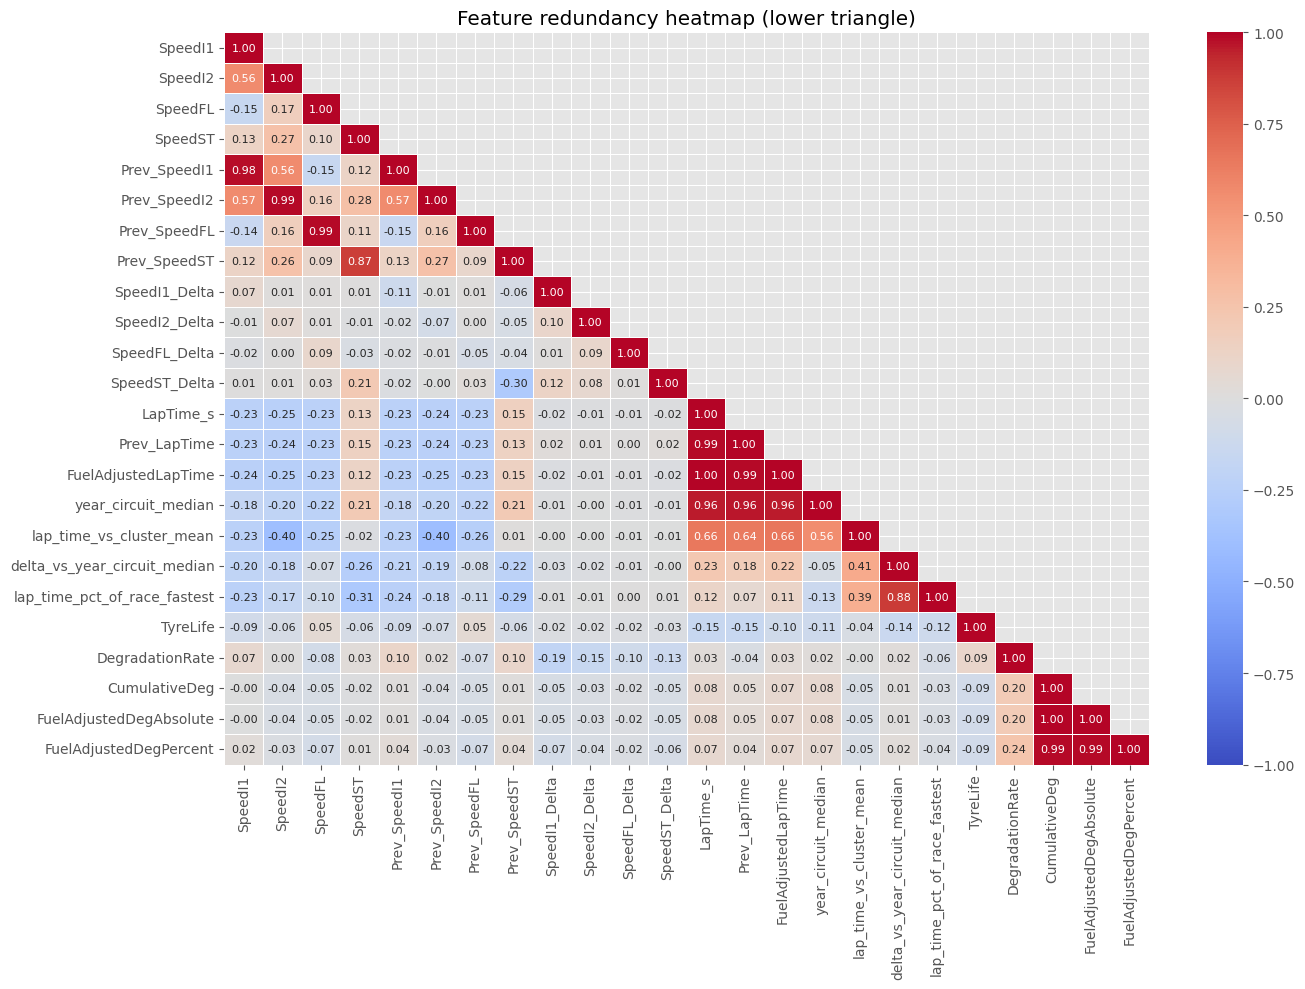

In [18]:
corr_df = compute_target_correlations(df)

print(f"Features with |corr| > 0.3  with LapTime_s: {(corr_df['abs_corr'] > 0.30).sum()}")
print(f"Features with |corr| > 0.05 with LapTime_s: {(corr_df['abs_corr'] > 0.05).sum()}")
print(f"Features with |corr| < 0.05 (near zero):    {(corr_df['abs_corr'] < 0.05).sum()}")
print(f"\nTop 15:\n{corr_df.head(15).to_string()}")
print(f"\nBottom 10 (weakest signal):\n{corr_df.tail(10).to_string()}")

plot_target_correlations(corr_df, top_n=30)

# Redundancy check on known correlated groups
redundancy_groups = {
    'sector_speeds':   ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST'],
    'prev_speeds':     ['Prev_SpeedI1', 'Prev_SpeedI2', 'Prev_SpeedFL', 'Prev_SpeedST'],
    'speed_deltas':    ['SpeedI1_Delta', 'SpeedI2_Delta', 'SpeedFL_Delta', 'SpeedST_Delta'],
    'laptime_family':  ['LapTime_s', 'Prev_LapTime', 'FuelAdjustedLapTime',
                        'year_circuit_median', 'lap_time_vs_cluster_mean',
                        'delta_vs_year_circuit_median', 'lap_time_pct_of_race_fastest'],
    'degradation':     ['TyreLife', 'DegradationRate', 'CumulativeDeg',
                        'FuelAdjustedDegAbsolute', 'FuelAdjustedDegPercent'],
}

plot_redundancy_heatmap(df, redundancy_groups)


### What we see

**Leakage alert — 4 features must be dropped from N06:**

| Feature | Why it's leakage |
|---------|-----------------|
| `FuelAdjustedLapTime` | corr = 0.999 — it IS LapTime_s + a tiny constant. Giving the model the answer. |
| `Sector1_s`, `Sector2_s`, `Sector3_s` | Sector times sum to lap time by definition. |
| `lap_time_vs_cluster_mean` | = LapTime_s − cluster_mean. Directly encodes the target. |
| `delta_vs_year_circuit_median` | = LapTime_s − year_circuit_median. Same problem. |

These features have high correlation precisely because they contain the target. Including them
would give the model an almost-free prediction and produce misleadingly perfect metrics.

**Strong legitimate predictors (top of the bar chart):**
- `Prev_LapTime` (0.989): the strongest real signal — your previous lap is the best predictor
  of your next lap. Sequential dependency is the dominant pattern.
- `year_circuit_median` (0.960): the session pace baseline. Valid — it's a race-level aggregate,
  not derived from the individual lap's own time.
- `Cluster` (−0.721): circuit archetype drives absolute lap time. Negative because low cluster
  IDs happen to correspond to faster circuits in our K-Means assignment.

**Redundancies confirmed in the heatmap:**
- `Prev_SpeedI1` / `SpeedI1`: 0.98 → keep only `SpeedI1`, drop the Prev version
- `Prev_SpeedI2` / `SpeedI2`: 0.99 → keep only `SpeedI2`
- `Prev_SpeedFL` / `SpeedFL`: 0.99 → keep only `SpeedFL`
- `CumulativeDeg` / `FuelAdjustedDegAbsolute`: 1.00 → identical, keep `CumulativeDeg`
- `FuelAdjustedDegAbsolute` / `FuelAdjustedDegPercent`: 0.99 → keep `FuelAdjustedDegPercent`

**Near-zero signal (|corr| < 0.05):** `DegradationRate`, `Year`, `DegAcceleration`,
all speed deltas, `LapTime_Trend`. These survive the linear filter — XGBoost may still find
non-linear interactions — but they are candidates for the OUT list in Step 9.

**`track_status_clean` → NaN**: zero variance after our baseline filter (all laps are `0 = clean`).
Drop unconditionally.

**`Year` corr = 0.019** — this is expected. Year alone says nothing about lap time without
knowing the circuit. Its value is as a drift anchor in combination with other features, not
as a standalone predictor.


---

## Step 7: Feature Pruning

Based on Step 6 findings, we now drop every confirmed leaky or redundant feature from the
working dataframe. This produces the **clean feature set** that enters N06.

**Drop list:**

| Feature(s) | Reason |
|-----------|--------|
| `FuelAdjustedLapTime` | Leakage — 0.999 corr with target |
| `Sector1_s`, `Sector2_s`, `Sector3_s` | Leakage — sector times sum to lap time |
| `lap_time_vs_cluster_mean` | Leakage — `LapTime_s − cluster_mean` |
| `delta_vs_year_circuit_median` | Leakage — `LapTime_s − year_circuit_median` |
| `track_status_clean` | Zero variance after baseline filter (all 0) |
| `Prev_SpeedI1`, `Prev_SpeedI2`, `Prev_SpeedFL` | 0.98–0.99 corr with their current-lap counterpart |
| `FuelAdjustedDegAbsolute` | 1.00 corr with `CumulativeDeg` — identical information |

In [19]:
LEAKAGE = [
    'FuelAdjustedLapTime',
    'Sector1_s', 'Sector2_s', 'Sector3_s',
    'lap_time_vs_cluster_mean',
    'delta_vs_year_circuit_median',
]

REDUNDANT = [
    'track_status_clean',     # zero variance post-filter
    'Prev_SpeedI1',           # corr 0.98 with SpeedI1
    'Prev_SpeedI2',           # corr 0.99 with SpeedI2
    'Prev_SpeedFL',           # corr 0.99 with SpeedFL
    'FuelAdjustedDegAbsolute', # corr 1.00 with CumulativeDeg
]

DROP_COLS = LEAKAGE + REDUNDANT


def prune_features(df: 'pd.DataFrame') -> 'pd.DataFrame':
    """Drop leaky and redundant columns identified in Step 6."""
    to_drop = [c for c in DROP_COLS if c in df.columns]
    out = df.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} columns: {to_drop}")
    print(f"Columns: {df.shape[1]} -> {out.shape[1]}")
    return out


# ── Run ──
df = prune_features(df)


Dropped 11 columns: ['FuelAdjustedLapTime', 'Sector1_s', 'Sector2_s', 'Sector3_s', 'lap_time_vs_cluster_mean', 'delta_vs_year_circuit_median', 'track_status_clean', 'Prev_SpeedI1', 'Prev_SpeedI2', 'Prev_SpeedFL', 'FuelAdjustedDegAbsolute']
Columns: 56 -> 45


### What we see

**56 → 45 columns** — 11 features dropped, zero errors.

**Leakage removed (6):** `FuelAdjustedLapTime`, `Sector1_s`, `Sector2_s`, `Sector3_s`,
`lap_time_vs_cluster_mean`, and `delta_vs_year_circuit_median` are gone.
The model can no longer reach the target through a back-door.

**Redundancies removed (5):** `track_status_clean` (zero variance after baseline filter),
`Prev_SpeedI1` / `Prev_SpeedI2` / `Prev_SpeedFL` (0.98–0.99 corr with their current-lap
counterparts), and `FuelAdjustedDegAbsolute` (1.00 corr with `CumulativeDeg`).

**Two minor flags carried forward to N06:**

| Column | Note |
|--------|------|
| `Prev_SpeedST` | Not dropped — `SpeedST` has 8.8% nulls so the pair correlation is noisier than the others. Confirm in N06. |
| `FuelEffect` | = `(TyreLife − stint_start) × 0.055` — linear transform of `TyreLife`. Candidate for DROP if XGBoost gain is near zero. |

**Remaining 45 columns:** 1 target (`LapTime_s`), 3 raw strings (`Driver`, `GP_Name`, `Team`
— encoding handled in N06), and 41 numeric/categorical features ready for modelling.


---

## Step 8: Outlier Analysis

Our baseline filter in N04 removed `LapTime_s > 180s`, but that's a loose cap.
After cleaning, the target still has a max of ~150s and the `delta_vs_year_circuit_median`
reached +67s in Step 4 — evidence that residual outliers survived.

Here we quantify how many, where they come from, and decide what to do with them.


LapTime_s — global stats
  P01 / P99      : 69.97s  /  112.59s
  IQR fence (×3) : 30.75s  /  147.60s
  Min / Max       : 67.01s  /  148.99s

  Above P99  : 454 laps  (1.00%)
  Below P01  : 453 laps  (1.00%)

Per-circuit CV (top 10 — highest dispersion):
GP_Name
Monaco              8.598
Montréal            7.756
São Paulo           7.114
Zandvoort           5.608
Mexico City         4.775
Silverstone         4.168
Suzuka              3.118
Lusail              2.362
Spa-Francorchamps   2.325
Melbourne           2.172

Compound breakdown of P99 outliers (454 laps):
Compound
MEDIUM          271
SOFT            143
HARD             35
INTERMEDIATE      4
WET               1


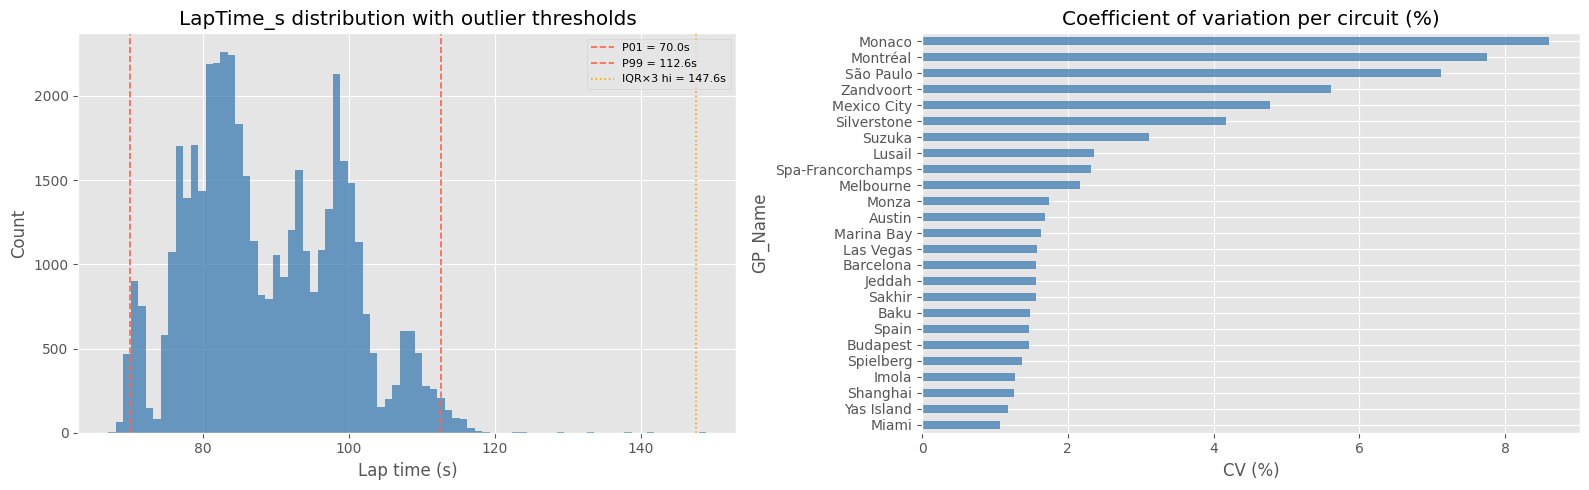

In [20]:
def analyse_outliers(df, target='LapTime_s'):
    p01 = df[target].quantile(0.01)
    p99 = df[target].quantile(0.99)
    iqr = df[target].quantile(0.75) - df[target].quantile(0.25)
    iqr_lo = df[target].quantile(0.25) - 3 * iqr
    iqr_hi = df[target].quantile(0.75) + 3 * iqr

    print(f"LapTime_s — global stats")
    print(f"  P01 / P99      : {p01:.2f}s  /  {p99:.2f}s")
    print(f"  IQR fence (×3) : {iqr_lo:.2f}s  /  {iqr_hi:.2f}s")
    print(f"  Min / Max       : {df[target].min():.2f}s  /  {df[target].max():.2f}s")

    mask_hi = df[target] > p99
    mask_lo = df[target] < p01
    print(f"\n  Above P99  : {mask_hi.sum():,} laps  ({mask_hi.mean()*100:.2f}%)")
    print(f"  Below P01  : {mask_lo.sum():,} laps  ({mask_lo.mean()*100:.2f}%)")

    # Per-circuit CV
    cv = (
        df.groupby('GP_Name')[target]
          .agg(lambda x: x.std() / x.mean() * 100)
          .rename('CV_%')
          .sort_values(ascending=False)
    )
    print(f"\nPer-circuit CV (top 10 — highest dispersion):")
    print(cv.head(10).to_string())

    # Compound breakdown of the outliers
    print(f"\nCompound breakdown of P99 outliers ({mask_hi.sum()} laps):")
    print(df[mask_hi]['Compound'].value_counts().to_string())

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(df[target], bins=80, color='steelblue', alpha=0.8, edgecolor='none')
    axes[0].axvline(p01, color='tomato',  linestyle='--', linewidth=1.2, label=f'P01 = {p01:.1f}s')
    axes[0].axvline(p99, color='tomato',  linestyle='--', linewidth=1.2, label=f'P99 = {p99:.1f}s')
    axes[0].axvline(iqr_hi, color='orange', linestyle=':', linewidth=1.2, label=f'IQR×3 hi = {iqr_hi:.1f}s')
    axes[0].set_title('LapTime_s distribution with outlier thresholds')
    axes[0].set_xlabel('Lap time (s)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=8)

    cv_plot = cv.sort_values(ascending=True)
    cv_plot.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
    axes[1].set_title('Coefficient of variation per circuit (%)')
    axes[1].set_xlabel('CV (%)')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'outlier_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    return p01, p99

p01, p99 = analyse_outliers(df)


### What we see

**Global range:** P01 = 70.0s (Spielberg, fastest circuit) — P99 = 112.6s (Spa/Baku tier).
The IQR×3 upper fence sits at 147.6s and the actual maximum is 149.0s — only a handful of
laps even breach that conservative threshold. The distribution is right-skewed but not
pathologically so.

**454 above P99 (1.00%) — decision: keep.**
- Compound breakdown: 271 MEDIUM + 143 SOFT. These are almost entirely pit-out laps or
  track-position laps where a driver was on a slow in-lap, not timing anomalies.
- The IQR×3 fence at 147.6s already captures the full range (max = 149.0s). Any clip
  below P99 would remove legitimate racing laps. XGBoost is robust to these natively.

**453 below P01 (1.00%) — decision: keep.**
- Min = 67.0s — entirely from Spielberg, the shortest circuit. Legitimate fast laps,
  not data errors.

**Circuit CV breakdown:**
- **Monaco (8.6%)** and **Montréal (7.8%)** are expected outliers: Monaco has enormous
  variance due to slow sector combinations, racing incidents, and DRS barely open.
  Montréal 2024 was rain/SC-affected (same artefact noted in Step 3).
- **São Paulo (7.1%):** same rain/SC confound from Step 3.
- **Miami (0.8%):** extremely consistent circuit — low variance, predictable pace.

**Overall decision: no clipping applied.** The data is clean enough after N04's 180s cap.
N06 will handle distributional tails through XGBoost's native split mechanism and
the temporal train/val split will expose any residual sensitivity to outliers.


---

## Step 9: Final Feature Set & Manifest Export

All analysis complete. This step consolidates the decisions from Steps 6–8 into an explicit
**IN / OUT** feature registry and exports  for N06 to consume.

### Features OUT (and why)

| Feature | Reason |
|---------|--------|
|  | Leakage (Step 6) |
| , ,  | Leakage — sum to target (Step 6) |
|  | Leakage — derived from target (Step 6) |
|  | Leakage — derived from target (Step 6) |
|  | Zero variance post-filter (Step 6) |
| , ,  | 0.98–0.99 corr with current-lap counterpart (Step 6) |
|  | 1.00 corr with  (Step 6) |
| , ,  | Raw strings — identity encoded via  /  /  |

### Categorical encoding (handled in N06)

| Feature | Encoding |
|---------|---------|
|  | Ordinal: SOFT=0, MEDIUM=1, HARD=2, INTERMEDIATE=3, WET=4 |
|  | Ordinal: early=0, mid=1, late=2 |
|  | Boolean → int (already 0/1) |

### Model outcome (N06)

N06 iterated through a global model (Step 7–8), per-cluster splits (Steps 5 & 8), and a
**delta formulation** (Step 9). The delta model — predicting lap-to-lap time change
() instead of absolute time — was chosen as the single production output:

- Val 2024 MAE: **0.461 s** — Test 2025 MAE: **0.392 s** — R²: **0.996**
- Saves to 
- 2-lap warm-up required per stint ( undefined at stint start)


In [21]:
def export_feature_manifest(df: 'pd.DataFrame', out_path: 'Path') -> dict:
    """Build and save the feature manifest for N06 to consume."""
    features_in = [
        c for c in df.columns
        if c not in ['LapTime_s', 'Driver', 'GP_Name', 'Team']
        and df[c].dtype != 'object'
        and df[c].dtype.name != 'category'
    ]

    categorical_encoding = {
        'Compound':   {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4},
        'race_phase': {'early': 0, 'mid': 1, 'late': 2},
        'FreshTyre':  'bool_to_int',
    }

    manifest = {
        'target': 'LapTime_s',
        'features_in': features_in,
        'features_out': {
            'leakage':   [
                'FuelAdjustedLapTime',
                'Sector1_s', 'Sector2_s', 'Sector3_s',
                'lap_time_vs_cluster_mean',
                'delta_vs_year_circuit_median',
            ],
            'redundant': [
                'track_status_clean',
                'Prev_SpeedI1', 'Prev_SpeedI2', 'Prev_SpeedFL',
                'FuelAdjustedDegAbsolute',
            ],
            'raw_strings': ['Driver', 'GP_Name', 'Team'],
        },
        'categorical_encoding': categorical_encoding,
        'n_features':    len(features_in),
        'n_laps_train':  int((df['Year'] == 2023).sum()),
        'n_laps_val':    int((df['Year'] == 2024).sum()),
    }

    with open(out_path, 'w') as f:
        json.dump(manifest, f, indent=2)

    print(f"Manifest saved -> {out_path}")
    print(f"Features IN  : {manifest['n_features']}")
    print(f"Train laps   : {manifest['n_laps_train']:,}  (2023)")
    print(f"Val laps     : {manifest['n_laps_val']:,}  (2024)")
    print(f"Feature list:")
    for j, feat in enumerate(features_in, 1):
        print(f"  {j:02d}. {feat}")
    return manifest


# ── Run ──
out_path = PROCESSED / 'feature_manifest_laptime.json'
manifest = export_feature_manifest(df, out_path)


Manifest saved -> c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\feature_manifest_laptime.json
Features IN  : 39
Train laps   : 22,106  (2023)
Val laps     : 23,256  (2024)
Feature list:
  01. DriverNumber
  02. LapNumber
  03. Stint
  04. SpeedI1
  05. SpeedI2
  06. SpeedFL
  07. SpeedST
  08. TyreLife
  09. FreshTyre
  10. Position
  11. CompoundID
  12. TeamID
  13. LapsSincePitStop
  14. FuelLoad
  15. Year
  16. FuelEffect
  17. FuelAdjustedDegPercent
  18. Prev_LapTime
  19. Prev_TyreLife
  20. Prev_SpeedST
  21. LapTime_Delta
  22. SpeedI1_Delta
  23. SpeedI2_Delta
  24. SpeedFL_Delta
  25. SpeedST_Delta
  26. LapTime_Trend
  27. DegradationRate
  28. CumulativeDeg
  29. DegAcceleration
  30. AirTemp
  31. TrackTemp
  32. Humidity
  33. Rainfall
  34. laps_remaining
  35. Cluster
  36. mean_sector_speed
  37. lap_time_pct_of_race_fastest
  38. year_circuit_median
  39. team_pace_rank
